In [30]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [31]:
output_path_figures = os.path.join('output', 'figures', 'final_questionnaire')
output_path_general = os.path.join('output')

In [32]:
number_of_participants = 30

In [33]:
survey_structure = 'limesurvey_survey_367366.txt'
survey_overview = pd.read_csv(os.path.join('input', 'surveys', 'final', survey_structure), sep='\t')
survey_overview.head()

,id,related_id,class,type/scale,name,relevance,text,help,language,validation,...,time_limit_warning,time_limit_warning_2,time_limit_warning_2_display_time,time_limit_warning_2_message,time_limit_warning_2_style,time_limit_warning_display_time,time_limit_warning_message,time_limit_warning_style,use_dropdown,value_range_allows_missing
0,NaN,NaN,S,NaN,sid,NaN,367366,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,S,NaN,gsid,NaN,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,S,NaN,admin,NaN,inherit,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,S,NaN,adminemail,NaN,inherit,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,S,NaN,anonymized,NaN,N,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
# read the survey data
survey_filename = 'results-survey367366.csv'
survey_responses = pd.read_csv(os.path.join('input', 'surveys', 'final', survey_filename), sep='\t')
print(survey_responses.head())

column_names = list(survey_responses.columns)

# character to separate question code and description
qs_separator = '$'

parsed_column_names = []
for name in column_names:
    split_name = name.split(qs_separator)
    question_code = split_name[0] # separate question code from description text
    parsed_column_names.append([question_code, split_name[1]])

column_names_df = pd.DataFrame(data=parsed_column_names, columns=['questioncode', 'description'])

survey_responses.columns = column_names_df.loc[: , 'questioncode']
column_names_df = column_names_df.set_index('questioncode')
display(column_names_df)

display(survey_responses)

   id$ Response ID submitdate$ Date submitted  lastpage$ Last page  \
0               13        2025-03-07 23:20:57                    2   
1               14        2025-03-07 23:22:03                    2   
2               15        2025-03-10 09:56:57                    2   
3               16        2025-03-10 09:57:55                    2   
4               17        2025-03-10 23:32:23                    2   

  startlanguage$ Start language  seed$ Seed startdate$ Date started  \
0                            en   443067577     2025-03-07 22:51:01   
1                            en  2077111476     2025-03-07 22:51:05   
2                            en  1428815588     2025-03-10 09:42:45   
3                            en   696079778     2025-03-10 09:42:58   
4                            en  1886500179     2025-03-10 22:26:20   

  datestamp$ Date last action  \
0         2025-03-07 23:20:57   
1         2025-03-07 23:22:03   
2         2025-03-10 09:56:57   
3         2025-03-10

,description
questioncode,
id,Response ID
submitdate,Date submitted
lastpage,Last page
startlanguage,Start language
seed,Seed
...,...
G02Q05Time,Question time: G02Q05
G02Q08Time,Question time: G02Q08
G02Q08CopyTime,Question time: G02Q08Copy


questioncode,id,submitdate,lastpage,startlanguage,seed,startdate,datestamp,Q00[SQ001],Q00[SQ002],Q00[SQ003],...,G02Q10Time,G02Q10CopyTime,G02Q04Time,G02Q07Time,G02Q07CopyTime,G02Q05Time,G02Q08Time,G02Q08CopyTime,G02Q09Time,G02Q09CopyTime
0,13,2025-03-07 23:20:57,2,en,443067577,2025-03-07 22:51:01,2025-03-07 23:20:57,AO05,AO03,AO02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14,2025-03-07 23:22:03,2,en,2077111476,2025-03-07 22:51:05,2025-03-07 23:22:03,AO03,AO02,AO03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,15,2025-03-10 09:56:57,2,en,1428815588,2025-03-10 09:42:45,2025-03-10 09:56:57,AO03,AO04,AO04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,16,2025-03-10 09:57:55,2,en,696079778,2025-03-10 09:42:58,2025-03-10 09:57:55,AO04,AO01,AO05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,17,2025-03-10 23:32:23,2,en,1886500179,2025-03-10 22:26:20,2025-03-10 23:32:23,AO04,AO02,AO04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,18,2025-03-15 09:37:03,2,en,1505906473,2025-03-15 08:45:41,2025-03-15 09:37:03,AO04,AO02,AO03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,21,2025-03-21 12:37:11,2,en,1460512131,2025-03-21 12:14:50,2025-03-21 12:37:11,AO03,AO02,AO03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,22,2025-03-21 12:32:24,2,en,1960935142,2025-03-21 12:15:07,2025-03-21 12:32:24,AO03,AO04,AO04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,23,2025-03-26 16:05:53,2,en,302549497,2025-03-26 15:39:38,2025-03-26 16:05:53,AO03,AO02,AO04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,24,2025-03-26 17:31:07,2,en,1818709022,2025-03-26 17:11:41,2025-03-26 17:31:07,AO02,AO04,AO03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# remove test participants
def remove_participant(df, participant_id, col = 'participant_id'):
    entries = df[df[col] == participant_id]
    return df.drop(entries.index)

In [36]:
# Map answer codes to options

#rating
rating_data = [
    ['AO01', 'strongly_disagree', 1, 'Strongly Disagree'],
    ['AO02', 'disagree', 2, 'Disagree'],
    ['AO03', 'neutral', 3, 'Neutral'],
    ['AO04', 'agree', 4, 'Agree'],
    ['AO05', 'strongly_agree', 5, 'Strongly Agree'],
]
rating = pd.DataFrame(data=rating_data, columns=['answer_code', 'option', 'value', 'label'])

comparison_answers = {
    "AO01": "First option",
    "AO02": "Second option"
}

In [37]:
#declaring the questions here, any other questions are free text questions

sus_questions = ['Q00[SQ001]', 'Q00[SQ002]', 'Q00[SQ003]', 'Q00[SQ004]', 'Q00[SQ005]', 'Q00[SQ006]', 'Q00[SQ007]', 'Q00[SQ008]', 'Q00[SQ009]', 'Q00[SQ010]']

feedback_questions = ['G01Q02[SQ001]', 'G01Q02[SQ002]', 'G01Q02[SQ003]', 'G01Q02[SQ004]', 'G01Q02[SQ005]']

#CSI
creativity_questions = [
    "G01Q13[SQ001]", 
    "G01Q13[SQ002]", 
    "G01Q13[SQ003]", 
    "G01Q13[SQ004]", 
    "G01Q13[SQ005]", 
    "G01Q13[SQ006]", 
    "G01Q13[SQ007]", 
    "G01Q13[SQ008]", 
    "G01Q13[SQ009]", 
    "G01Q13[SQ010]",
    "G01Q13[SQ011]",
    "G01Q13[SQ012]"
]

ai_toolset_ratings = [
    "G02Q03[SQ001]",
    "G02Q03[SQ009]",
    "G02Q03[SQ010]",
    "G02Q03[SQ011]",
    "G02Q03[SQ012]",
    "G02Q03[SQ013]",
    "G02Q03[SQ002]",
    "G02Q03[SQ005]"
]

ai_agent_ratings = [
    "G02Q04[SQ001]",
    "G02Q04[SQ002]",
    "G02Q04[SQ003]",
    "G02Q04[SQ004]",
    "G02Q04[SQ005]",
    "G02Q04[SQ006]",
    "G02Q04[SQ007]",
    "G02Q04[SQ010]",
    "G02Q04[SQ009]"
]

task_ratings = [
    "G02Q05[SQ008]",
    "G02Q05[SQ003]",
    "G02Q05[SQ009]",
    "G02Q05[SQ011]",
    "G02Q05[SQ004]",
    "G02Q05[SQ012]",
    "G02Q05[SQ013]",
    "G02Q05[SQ014]",
    "G02Q05[SQ015]"
]

rating_questions = [*sus_questions, *feedback_questions, *ai_toolset_ratings, *ai_agent_ratings, *task_ratings]

comparison_questions = [
    "G01Q14[SQ001]", 
    "G01Q14[SQ002]", 
    "G01Q14[SQ003]", 
    "G01Q14[SQ004]", 
    "G01Q14[SQ005]", 
    "G01Q14[SQ006]", 
    "G01Q14[SQ007]", 
    "G01Q14[SQ008]", 
    "G01Q14[SQ009]", 
    "G01Q14[SQ010]",
    "G01Q14[SQ011]",
    "G01Q14[SQ012]",
    "G01Q14[SQ013]",
    "G01Q14[SQ014]",
    "G01Q14[SQ015]",
]


free_form_questions = ['G02Q10', 'G02Q10Copy', 'G02Q07', 'G02Q07Copy', 'G02Q08', 'G02Q08Copy', 'G02Q09', 'G02Q09Copy']

In [38]:
#divergent bar chart, taken from: https://stackoverflow.com/questions/23142358/create-a-diverging-stacked-bar-chart-in-matplotlib

def survey(results, category_names, split_labels = False, title_override = None, x_len = 90, step = 1, y_padding = 0.01, legend_y = -0.05):

    """
    Parameters
    ----------
    results : dict
        A mapping from question labels to a list of answers per category.
        It is assumed all lists contain the same number of entries and that
        it matches the length of *category_names*. The order is assumed
        to be from 'Strongly disagree' to 'Strongly aisagree'
    category_names : list of str
        The category labels.
    """

    labels = list(results.keys())
    category_names = [c.replace("_", " ") for c in category_names]
    data = np.array(list(results.values()))
    data_cum = data.cumsum(axis=1)
    middle_index = data.shape[1]//2
    offsets = data[:, range(middle_index)].sum(axis=1) + data[:, middle_index]/2
    # Color Mapping
    category_colors = plt.colormaps['coolwarm_r'](
        np.linspace(0.15, 0.85, data.shape[1]))

    fig, ax = plt.subplots(figsize=(10, 5))

    if split_labels:
        title = labels[0].split(" [")
        ax.set_title(title[0], pad=20)
        for i, label in enumerate(labels):
            labels[i] = label.split(" [")[1][:-1]
            
    if title_override is not None:
        ax.set_title(title_override, pad=20)

    # Plot Bars
    for i, (colname, color) in enumerate(zip(category_names, category_colors)):
        widths = data[:, i]
        starts = data_cum[:, i] - widths - offsets
        rects = ax.barh(labels, widths, left=starts, height=0.6,
                        label=colname, color=color)

    # Add Zero Reference Line
    ax.axvline(0, linestyle='--', color='black', alpha=.25)

    # X Axis
    ax.set_xlim(-x_len, x_len)
    ax.set_xticks(np.arange(-x_len, x_len + step, step))
    display(np.arange(-x_len, x_len + step, step))
    ax.xaxis.set_major_formatter(lambda x, pos: str(abs(int(x))))
    ax.xaxis.set_major_locator(plt.MaxNLocator(x_len / 5 * 2))

    # Y Axis
    ax.invert_yaxis()
    ax.set_yticklabels(labels)
    ax.tick_params(axis='y', which='both', length=0)
    
    # Remove spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # 5% padding on the y-axis and none on the x-axis
    ax.margins(None, y_padding)
    
    #Legend
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, legend_y),
      fancybox=False, shadow=False, ncol=5)

    # Set Background Color
    fig.set_facecolor('#FFFFFF')

    return fig, ax

questioncode,Q00[SQ001],Q00[SQ002],Q00[SQ003],Q00[SQ004],Q00[SQ005],Q00[SQ006],Q00[SQ007],Q00[SQ008],Q00[SQ009],Q00[SQ010],...,G02Q04[SQ009],G02Q05[SQ008],G02Q05[SQ003],G02Q05[SQ009],G02Q05[SQ011],G02Q05[SQ004],G02Q05[SQ012],G02Q05[SQ013],G02Q05[SQ014],G02Q05[SQ015]
0,strongly_agree,neutral,disagree,disagree,agree,strongly_disagree,strongly_agree,disagree,neutral,neutral,...,strongly_agree,agree,agree,agree,agree,AO06,strongly_agree,neutral,neutral,disagree
1,neutral,disagree,neutral,strongly_disagree,agree,neutral,agree,disagree,neutral,neutral,...,strongly_agree,strongly_agree,agree,agree,agree,AO06,agree,agree,strongly_agree,agree
2,neutral,agree,agree,strongly_disagree,neutral,neutral,disagree,agree,disagree,strongly_disagree,...,strongly_agree,disagree,strongly_disagree,disagree,AO06,agree,disagree,AO06,strongly_disagree,neutral
3,agree,strongly_disagree,strongly_agree,strongly_disagree,agree,strongly_disagree,strongly_agree,strongly_disagree,agree,disagree,...,strongly_agree,strongly_agree,disagree,strongly_agree,strongly_agree,AO06,strongly_agree,AO06,strongly_agree,strongly_agree
4,agree,disagree,agree,neutral,strongly_agree,strongly_disagree,agree,disagree,strongly_agree,disagree,...,agree,agree,strongly_agree,neutral,agree,strongly_agree,agree,agree,strongly_agree,strongly_disagree
5,agree,disagree,neutral,agree,agree,disagree,disagree,neutral,agree,neutral,...,agree,AO06,AO06,AO06,AO06,AO06,AO06,strongly_agree,disagree,strongly_disagree
6,neutral,disagree,neutral,disagree,agree,agree,strongly_agree,strongly_disagree,agree,disagree,...,neutral,agree,agree,agree,strongly_agree,strongly_agree,disagree,agree,disagree,neutral
7,neutral,agree,agree,strongly_disagree,disagree,agree,strongly_agree,agree,strongly_agree,strongly_disagree,...,disagree,agree,disagree,agree,agree,agree,strongly_disagree,neutral,disagree,agree
8,neutral,disagree,agree,disagree,neutral,neutral,disagree,agree,agree,strongly_disagree,...,strongly_agree,agree,strongly_agree,agree,strongly_agree,strongly_agree,agree,strongly_agree,strongly_agree,strongly_agree
9,disagree,agree,neutral,neutral,agree,neutral,disagree,neutral,neutral,neutral,...,disagree,neutral,agree,disagree,neutral,neutral,strongly_disagree,AO06,agree,disagree


{' Please rate the following aspects regarding the system you have just used [I found the interaction with the system natural]': [0,
  4,
  5,
  20,
  1],
 ' Please rate the following aspects regarding the system you have just used [I think that the system supported me to complete the task]': [1,
  1,
  8,
  14,
  6],
 ' Please rate the following aspects regarding the system you have just used [I think that the system made me reach the goal faster]': [0,
  4,
  11,
  8,
  7],
 ' Please rate the following aspects regarding the system you have just used [I found the system to look and feel similar to existing online text editors]': [1,
  7,
  4,
  7,
  11],
 ' Please rate the following aspects regarding the system you have just used [It felt like I was in control of the text during the task]': [1,
  6,
  4,
  15,
  4],
 ' Please rate the following statements regarding the usage of the AI Toolset (shortcuts for translate, extend, summarize and create comment).  AI Toolset    [I find the t

array([-30, -29, -28, -27, -26, -25, -24, -23, -22, -21, -20, -19, -18,
       -17, -16, -15, -14, -13, -12, -11, -10,  -9,  -8,  -7,  -6,  -5,
        -4,  -3,  -2,  -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,
         9,  10,  11,  12,  13,  14,  15,  16,  17,  18,  19,  20,  21,
        22,  23,  24,  25,  26,  27,  28,  29,  30])

/tmp/ipykernel_174599/1673836168.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(labels)


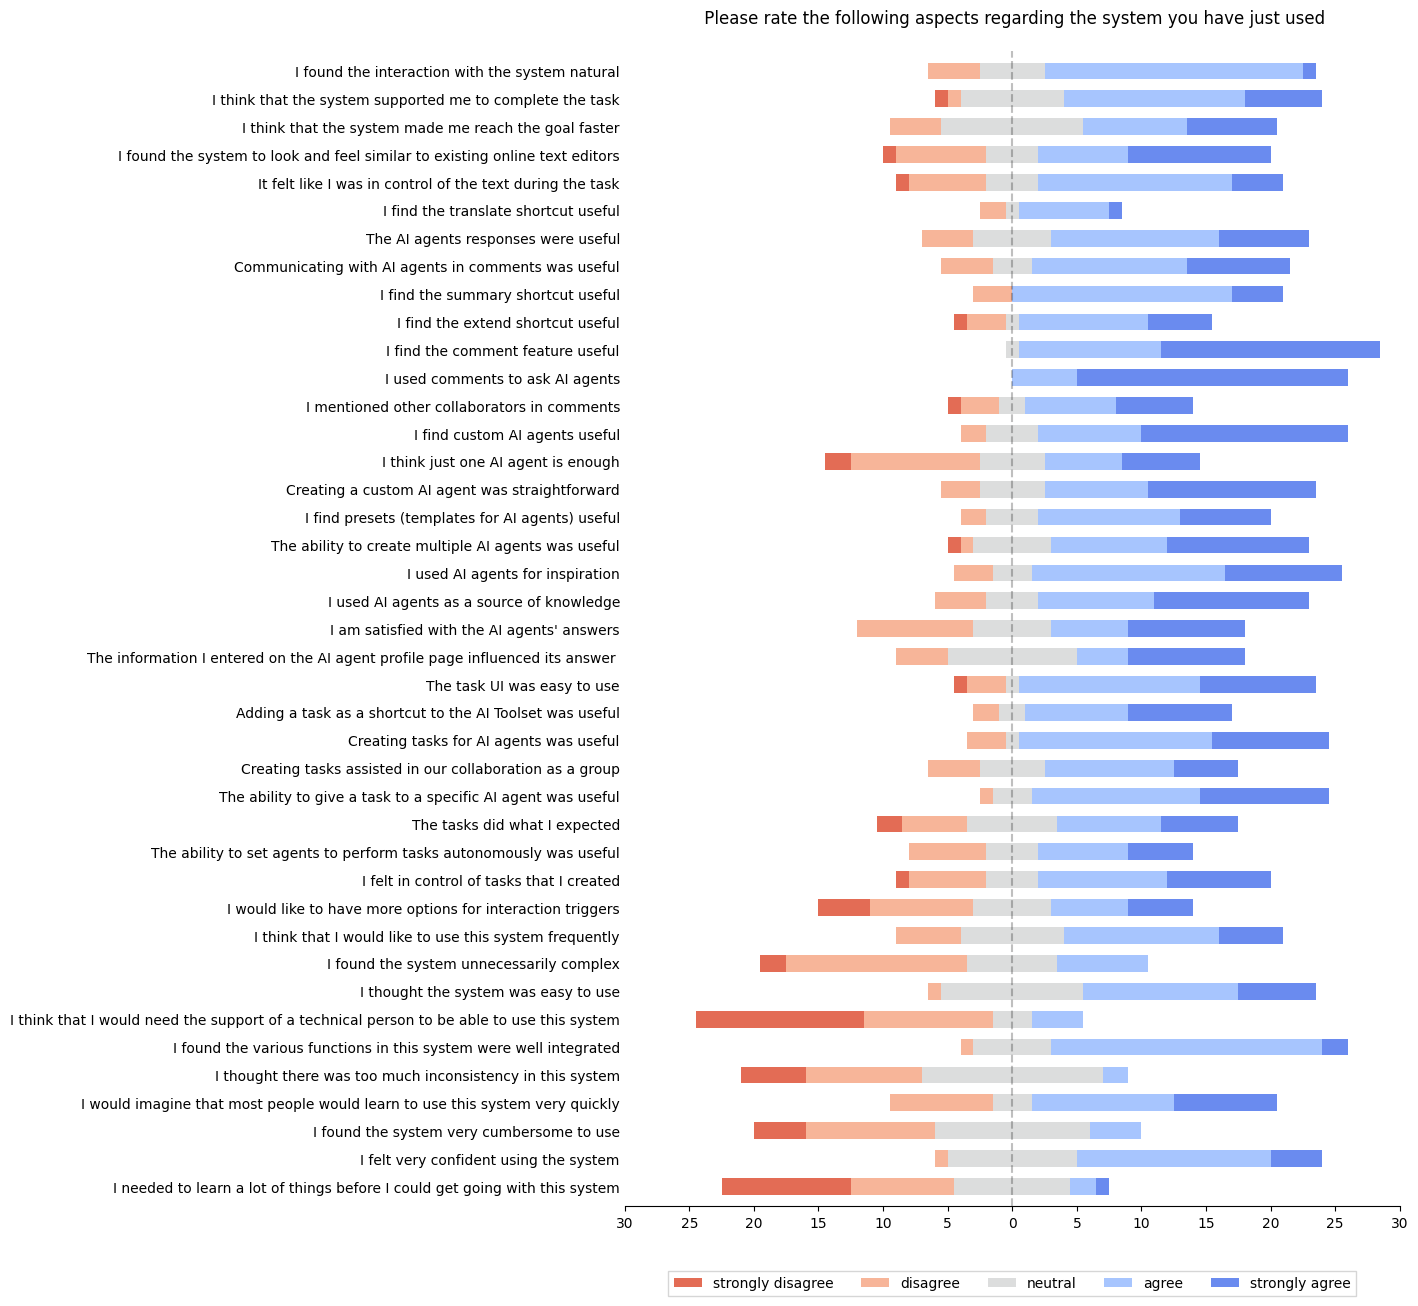

In [39]:
# ratings
rating_cols = [col for col in survey_responses if col.startswith(tuple(rating_questions))]
df_ratings = survey_responses[rating_cols]
df_ratings = df_ratings.replace(list(rating['answer_code']), list(rating['option']))

display(df_ratings)

melted = pd.melt(df_ratings)
counts = pd.crosstab(index=[melted['value']], columns=[melted['questioncode']]).transpose()
counts = counts[list(rating['option'])]

mapping = column_names_df['description'].to_dict()

counts = counts.rename(index=mapping)

display(counts.transpose().to_dict('list'))

fig, ax = survey(counts.transpose().to_dict('list'), list(rating['option']), split_labels=True, x_len=number_of_participants)

fig.set_figheight(15)

In [40]:
#compute SUS score
sus_scores = []
for index, row in df_ratings.iterrows():
    sum_odd = 0
    sum_even = 0
    for idx, sus_item in enumerate(sus_questions, start=1):
        if idx % 2 == 0: #even
            sum_even = sum_even + rating[rating['option'] == row[sus_item]]['value'].iloc[0]
        else: # odd
            sum_odd = sum_odd + rating[rating['option'] == row[sus_item]]['value'].iloc[0]

    X = sum_odd - 5
    Y = 25 - sum_even
    sus_score = (X+Y) * 2.5

    sus_scores.append(sus_score)

display("SUS score")
display(pd.Series(sus_scores).describe())

'SUS score'

count    30.000000
mean     66.916667
std      12.960207
min      45.000000
25%      57.500000
50%      67.500000
75%      75.000000
max      90.000000
dtype: float64

In [41]:
def divergent_chart(survey_responses, column_names_df, question_codes, number_of_participants, chart_name="divergent_bars_ratings.pdf"):
    question_cols = [col for col in survey_responses if col.startswith(tuple(question_codes))]
    df_questions = survey_responses[question_cols]
    df_questions = df_questions.replace(list(rating['answer_code']), list(rating['option']))
    
    melted = pd.melt(df_questions)
    counts = pd.crosstab(index=[melted['value']], columns=[melted['questioncode']]).transpose()
        
    # if a frequency option has not been selected, add a column with 0s
    rating_options = list(rating['option'])
    for r_option in rating_options:
      if not r_option in counts:
        counts[r_option] = 0
            
    counts = counts[list(rating['option'])]
    
    mapping = column_names_df['description'].to_dict()
    
    counts = counts.rename(index=mapping)
    
    #display(counts.transpose().to_dict('list'))
    
    fig, ax = survey(counts.transpose().to_dict('list'), list(rating['option']), split_labels=True, x_len=number_of_participants, y_padding=0.025, legend_y=-0.075)
    fig.set_figheight(5)
    plt.savefig(os.path.join(output_path_figures, chart_name), bbox_inches='tight')

array([-30, -29, -28, -27, -26, -25, -24, -23, -22, -21, -20, -19, -18,
       -17, -16, -15, -14, -13, -12, -11, -10,  -9,  -8,  -7,  -6,  -5,
        -4,  -3,  -2,  -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,
         9,  10,  11,  12,  13,  14,  15,  16,  17,  18,  19,  20,  21,
        22,  23,  24,  25,  26,  27,  28,  29,  30])

/tmp/ipykernel_174599/1673836168.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(labels)


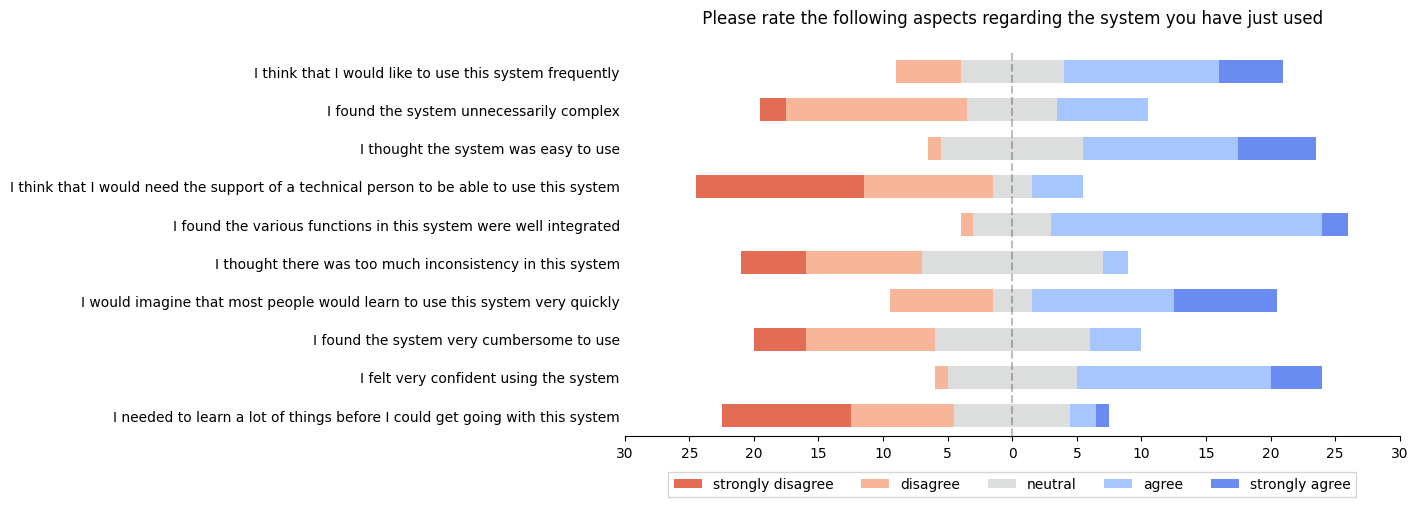

In [42]:
# sus ratings
divergent_chart(survey_responses, column_names_df, sus_questions, number_of_participants, "sus_ratings.pdf")

array([-30, -29, -28, -27, -26, -25, -24, -23, -22, -21, -20, -19, -18,
       -17, -16, -15, -14, -13, -12, -11, -10,  -9,  -8,  -7,  -6,  -5,
        -4,  -3,  -2,  -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,
         9,  10,  11,  12,  13,  14,  15,  16,  17,  18,  19,  20,  21,
        22,  23,  24,  25,  26,  27,  28,  29,  30])

/tmp/ipykernel_174599/1673836168.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(labels)


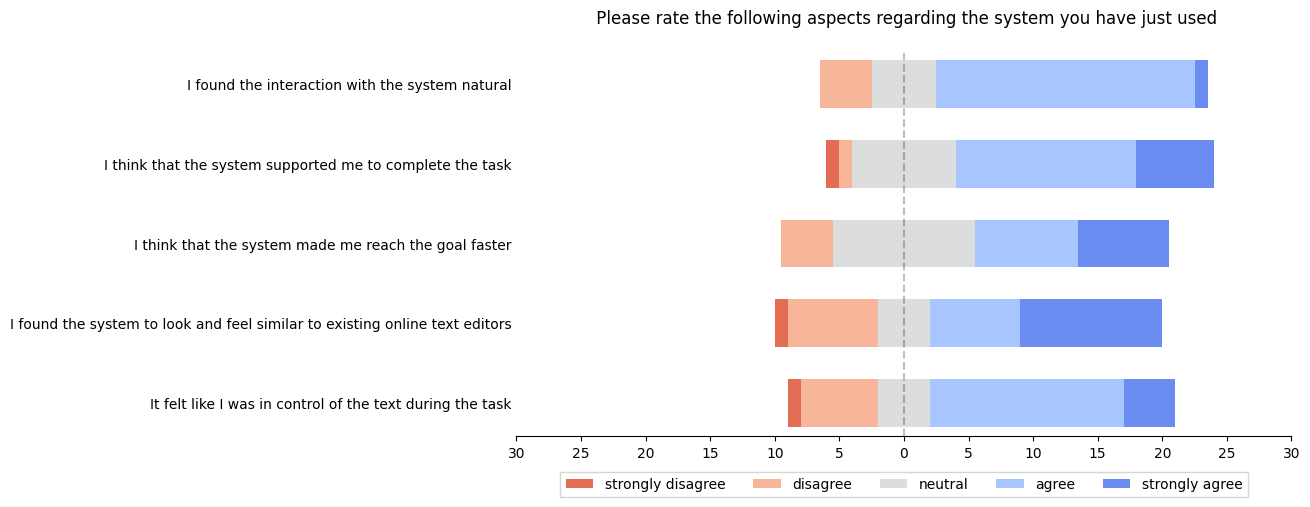

In [43]:
# feedback questions ratings (additional to sus)
divergent_chart(survey_responses, column_names_df, feedback_questions, number_of_participants, "general_feedback_ratings.pdf")

array([-30, -29, -28, -27, -26, -25, -24, -23, -22, -21, -20, -19, -18,
       -17, -16, -15, -14, -13, -12, -11, -10,  -9,  -8,  -7,  -6,  -5,
        -4,  -3,  -2,  -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,
         9,  10,  11,  12,  13,  14,  15,  16,  17,  18,  19,  20,  21,
        22,  23,  24,  25,  26,  27,  28,  29,  30])

/tmp/ipykernel_174599/1673836168.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(labels)


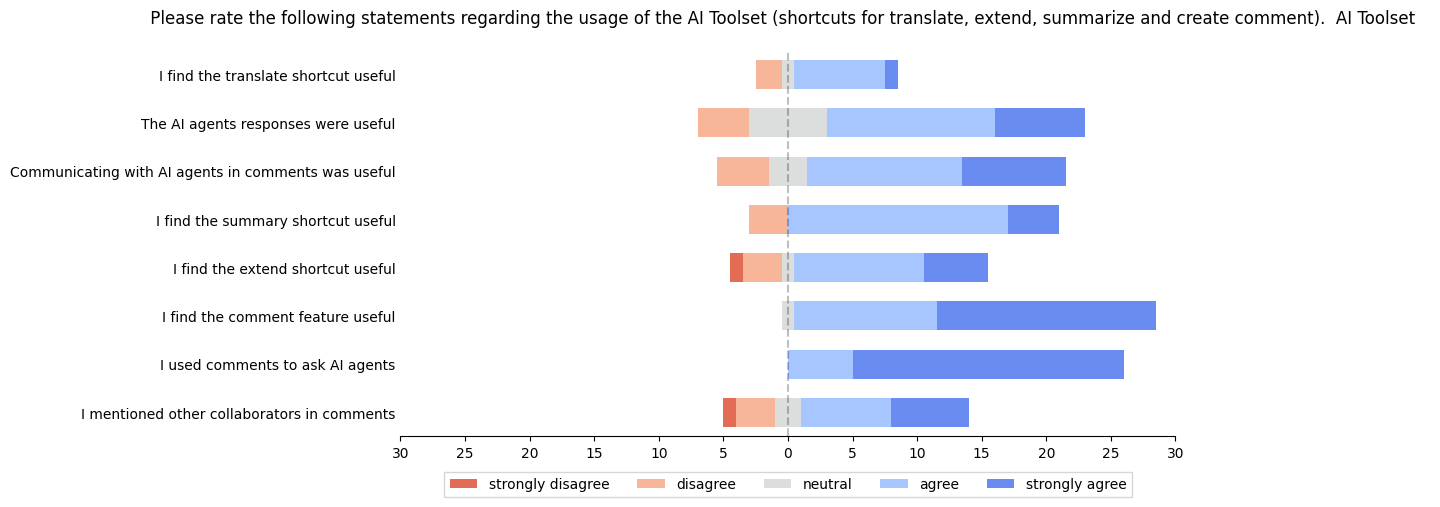

In [44]:
# ai_toolset_ratings
divergent_chart(survey_responses, column_names_df, ai_toolset_ratings, number_of_participants, "ai_toolset_ratings.pdf")

array([-30, -29, -28, -27, -26, -25, -24, -23, -22, -21, -20, -19, -18,
       -17, -16, -15, -14, -13, -12, -11, -10,  -9,  -8,  -7,  -6,  -5,
        -4,  -3,  -2,  -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,
         9,  10,  11,  12,  13,  14,  15,  16,  17,  18,  19,  20,  21,
        22,  23,  24,  25,  26,  27,  28,  29,  30])

/tmp/ipykernel_174599/1673836168.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(labels)


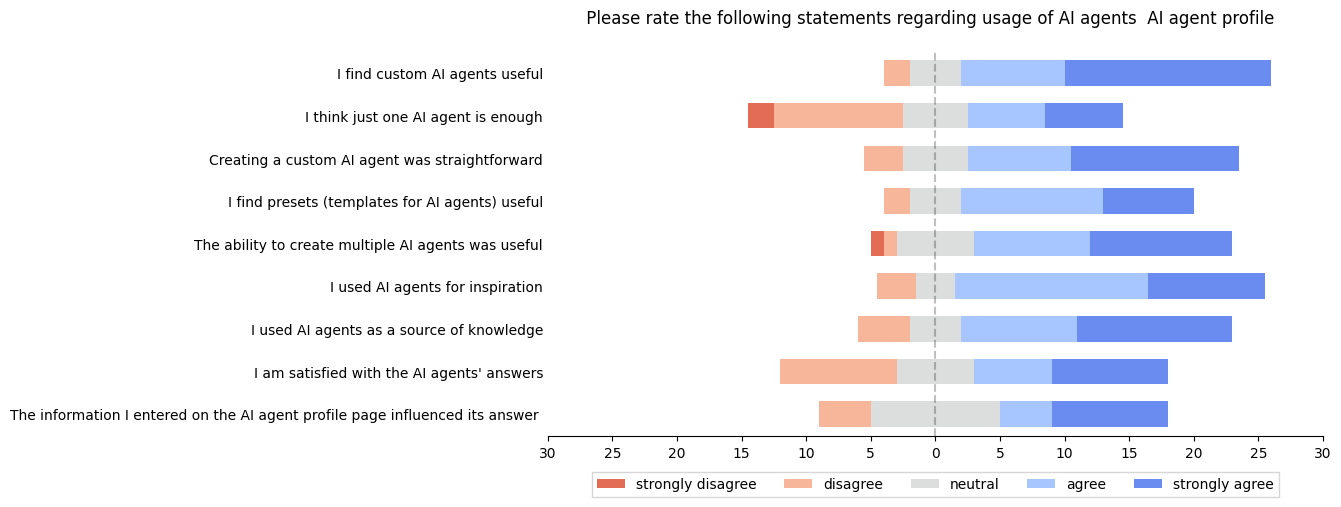

In [45]:
# ai_agent_ratings
divergent_chart(survey_responses, column_names_df, ai_agent_ratings, number_of_participants, "ai_agent_ratings.pdf")

array([-30, -29, -28, -27, -26, -25, -24, -23, -22, -21, -20, -19, -18,
       -17, -16, -15, -14, -13, -12, -11, -10,  -9,  -8,  -7,  -6,  -5,
        -4,  -3,  -2,  -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,
         9,  10,  11,  12,  13,  14,  15,  16,  17,  18,  19,  20,  21,
        22,  23,  24,  25,  26,  27,  28,  29,  30])

/tmp/ipykernel_174599/1673836168.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(labels)


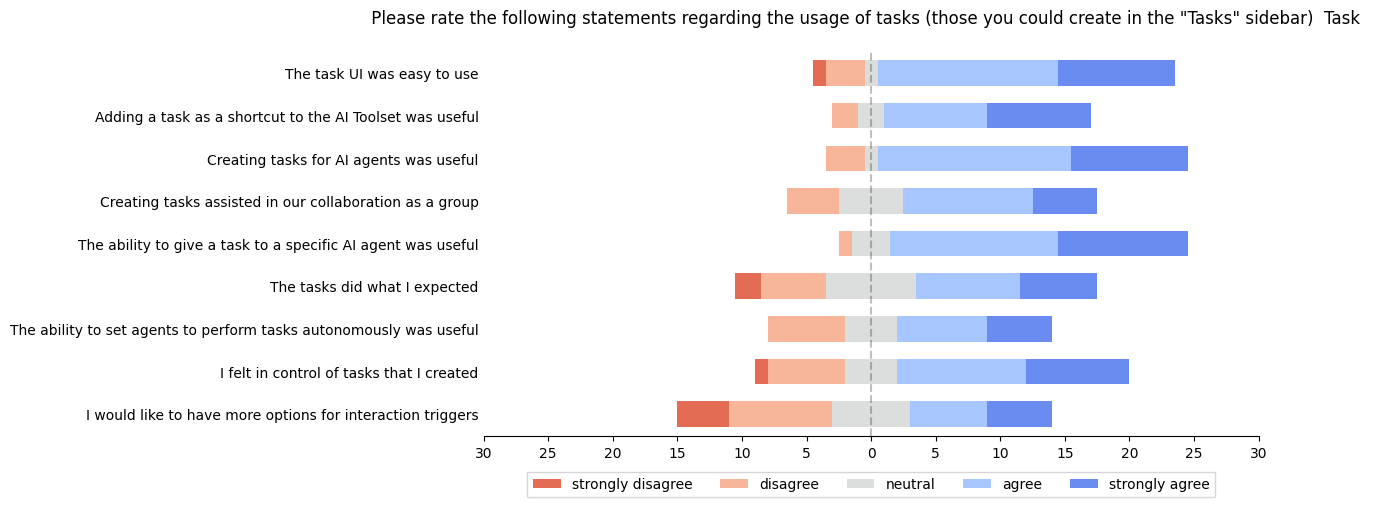

In [46]:
# task_ratings
divergent_chart(survey_responses, column_names_df, task_ratings, number_of_participants, "task_ratings.pdf")

In [47]:
#### Creativity Questions

In [48]:
creativity_mapping = {
    "G01Q13[SQ001]": "Collaboration",
    "G01Q13[SQ002]": "Enjoyment",
    "G01Q13[SQ003]": "Exploration",
    "G01Q13[SQ004]": "Expressiveness",
    "G01Q13[SQ005]": "Immersion",
    "G01Q13[SQ006]": "Results/Worth Effort",
    "G01Q13[SQ007]": "Enjoyment",
    "G01Q13[SQ008]": "Expressiveness",
    "G01Q13[SQ009]": "Results/Worth Effort",
    "G01Q13[SQ010]": "Collaboration",
    "G01Q13[SQ011]": "Exploration",
    "G01Q13[SQ012]": "Immersion",
}

In [49]:
# get answers for creativity questions
creativity_df = survey_responses[["id"] + creativity_questions].copy()
# melt the dataframe to get the answers in a single column
creativity_df = pd.melt(creativity_df, id_vars=["id"], value_vars=creativity_questions)
# assign catergory to each question
creativity_df["category"] = creativity_df["questioncode"].map(creativity_mapping)
# group by category for each interviewee
creativity_df = creativity_df.groupby(["id", "category"])["value"].sum().reset_index()
creativity_df.head(6)

,id,category,value
0,13,Collaboration,18
1,13,Enjoyment,17
2,13,Exploration,16
3,13,Expressiveness,14
4,13,Immersion,15
5,13,Results/Worth Effort,17


In [50]:
# options mapping
options_mapping = {
    "First option": 1,
    "Second option": 2
}

# map options to categories
categories_mapping = {
    "Be creative and expressive": "Expressiveness",  
    "Become immersed in the activity": "Immersion",
    "Enjoy using the system or tool": "Enjoyment",
    "Explore many different ideas, outcomes, or possibilities": "Exploration",
    "Produce results that are worth the effort I put in": "Results/Worth Effort",
    "Work with other people": "Collaboration"
}

# get columns and parse them with regular expressions
comparison_columns = column_names_df[column_names_df.index.isin(comparison_questions)]

comparion_options = list()

for index, row in comparison_columns.iterrows():
    question = row['description']
    # parse the question with regular expression
    match = re.search(r"\[(.*?)\]", question)
    if match:
        inside = match.group(1)

        # Now extract the two numbered items
        items = re.findall(r"\d\.\s*(.*?)(?=\d\.|$)", inside)
        comparion_options.append(items)
    elif index != "id":
        print(question)
        assert False, "No match"

# create a new dataframe to the options of comparison questions
comparison_columns = pd.concat(
    [
        comparison_columns, 
        pd.DataFrame(data=comparion_options, columns=['First option', 'Second option'], index=comparison_columns.index),
    ],
    axis=1,
)

print(comparison_columns)

                                                     description  \
questioncode                                                       
G01Q14[SQ001]   When working on the task in prototype, it’s m...   
G01Q14[SQ002]   When working on the task in prototype, it’s m...   
G01Q14[SQ003]   When working on the task in prototype, it’s m...   
G01Q14[SQ004]   When working on the task in prototype, it’s m...   
G01Q14[SQ005]   When working on the task in prototype, it’s m...   
G01Q14[SQ006]   When working on the task in prototype, it’s m...   
G01Q14[SQ007]   When working on the task in prototype, it’s m...   
G01Q14[SQ008]   When working on the task in prototype, it’s m...   
G01Q14[SQ009]   When working on the task in prototype, it’s m...   
G01Q14[SQ010]   When working on the task in prototype, it’s m...   
G01Q14[SQ011]   When working on the task in prototype, it’s m...   
G01Q14[SQ012]   When working on the task in prototype, it’s m...   
G01Q14[SQ013]   When working on the task in prot

In [51]:
def clean_string(s: str) -> str:
    s = s.replace('\xa0', ' ').replace('\u200b', '').replace('\ufeff', '')
    s = re.sub(r'\s+', ' ', s).strip()
    return s

# get comparison df but also save ID for correct split of CSI
comparison_df = survey_responses[["id"] + comparison_questions].copy()
comparison_df = comparison_df.melt(id_vars=["id"], value_vars=comparison_questions)
# join the options and the questions to the comparison dataframe
comparison_df = comparison_df.join(comparison_columns, on="questioncode")

selected_categories = dict()
for idx, row in comparison_df.iterrows():
    selected_option = row["value"]
    selected_option = clean_string(row[comparison_answers[selected_option]])
    # get category from mapping
    category = categories_mapping[selected_option]
    selected_categories[idx] = category


comparison_df["category"] = pd.Series(selected_categories)

# Group by ID and category and count the number of each category
comparison_df = comparison_df.groupby(["id", "category"]).size().reset_index(name="count")
comparison_df.head(6)

,id,category,count
0,13,Collaboration,3
1,13,Enjoyment,3
2,13,Exploration,3
3,13,Expressiveness,1
4,13,Immersion,1
5,13,Results/Worth Effort,4


In [52]:
# Get final CSI Score using formula
csi_df = creativity_df.merge(comparison_df, on=["id", "category"], how="left")

# Fill NaN values with 0
csi_df["count"] = csi_df["count"].fillna(0)

# Calculate the CSI score with formula
csi_df["CSI"] = csi_df["value"] * csi_df["count"]
csi_df = csi_df.groupby("id")["CSI"].sum().reset_index()
csi_df["CSI"] = csi_df["CSI"] / 3.0

# Describe results
csi_df["CSI"].describe()


count    30.000000
mean     67.211111
std      15.598527
min      31.000000
25%      56.833333
50%      65.500000
75%      79.000000
max      91.000000
Name: CSI, dtype: float64

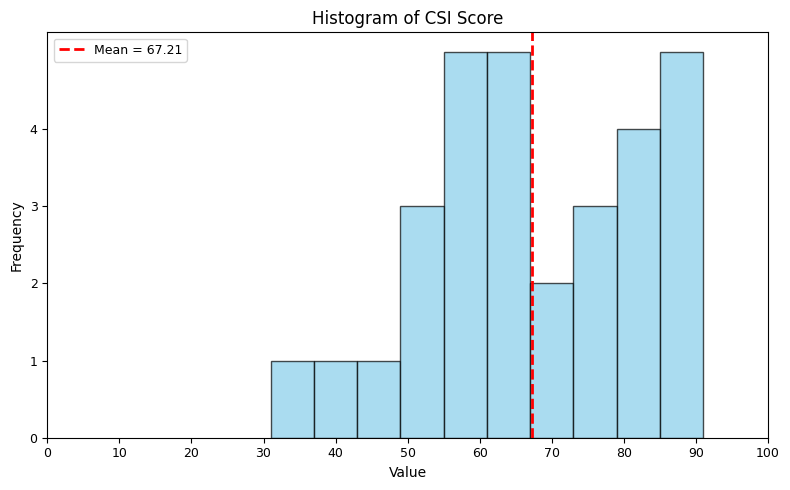

In [53]:
# Plot histogram and add mean
col = csi_df["CSI"]

mean = col.mean()
std = col.std()

plt.figure(figsize=(8, 5))
plt.hist(col, bins=10, color='skyblue', edgecolor='black', alpha=0.7)

# Mean line
plt.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean:.2f}')


plt.title("Histogram of CSI Score", fontsize=12)
plt.xlabel("Value", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.xticks(np.arange(0, 110, 10), fontsize=9)
plt.yticks(np.arange(0, 5, 1), fontsize=9)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(output_path_figures, "csi_histo.pdf"))

plt.show()

In [54]:
print(csi_df["CSI"])
csi_df = creativity_df.merge(comparison_df, on=["id", "category"], how="left")
csi_df["count"] = csi_df["count"].fillna(0)

0     83.333333
1     79.000000
2     65.333333
3     85.000000
4     70.333333
5     76.666667
6     58.333333
7     56.333333
8     55.000000
9     31.000000
10    79.000000
11    65.666667
12    47.666667
13    83.000000
14    89.666667
15    65.000000
16    91.000000
17    60.666667
18    86.000000
19    59.666667
20    49.000000
21    41.000000
22    61.666667
23    51.666667
24    89.666667
25    71.333333
26    50.000000
27    78.000000
28    63.000000
29    73.333333
Name: CSI, dtype: float64


In [55]:
grouped_csi = csi_df.groupby("category")[["value", "count"]].mean().round(2)
grouped_csi

,value,count
category,,
Collaboration,15.13,2.43
Enjoyment,14.13,2.53
Exploration,13.23,2.43
Expressiveness,12.30,1.97
Immersion,9.40,1.60
Results/Worth Effort,13.70,4.03


In [56]:
# extract free text repsonses

free_form_cols = [col for col in survey_responses if col.startswith(tuple(free_form_questions))]
df_free_form = survey_responses[free_form_cols]
display(df_free_form)

df_free_form.to_csv(os.path.join('output', 'final_free_form.csv'))

questioncode,G02Q10,G02Q10Copy,G02Q07,G02Q07Copy,G02Q08,G02Q08Copy,G02Q09,G02Q09Copy,G02Q10Time,G02Q10CopyTime,G02Q07Time,G02Q07CopyTime,G02Q08Time,G02Q08CopyTime,G02Q09Time,G02Q09CopyTime
0,AI comments feature is useful especially when ...,I didn't get the real purpose of the translate...,The feature of separating and giving an initia...,Some times the answers were too general but it...,NaN,NaN,I found the prototype useful for personal use ...,Sometimes AI answers can be confusing and you ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,most of the shortcuts were useful,translation did not work for our group,was rlly useful to get the AI agents responses...,-,in one task i could mention 3 to-dos and he ma...,-,"* AI-powered assistance, the idea that users c...",* over-reliance on AI: users may depend too mu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Use of AI integrated to the app without a need...,"Absent of preset features useful for essay, su...",I could give them the context and role so that...,I expected more useful preset agents for my ta...,NaN,"Unfortunately, interaction with tasks gave me ...","Comments, comments, comments, i.e. the ability...",Absence of notifications when somebody mention...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,I did not need to use external sources. Commun...,It was hard to follow comments/progress by oth...,"Fast reply, ability to replace the text immidi...",It would be nice to have grammar checking and ...,"Fast, give solution in a comment section. so y...",Took some time at first to understand the purp...,I would really need this function in my work a...,No sound notifications.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,The available toolset allows running manual ta...,It was a bit difficult to tell the difference ...,There is a set of predefined agents that were ...,The set of expertise and skills from AI sugges...,Very intuitive and easy way to create a task a...,The time period of running for some autonomous...,Writing with AI was a very exciting experience...,To many options for autonomous task triggers. ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,"It was very intuitive and time-saving, and imp...",Not being able to add more than one comment to...,"They were helpful in suggesting ideas, providi...",The names of the agents were somewhat difficul...,NaN,NaN,Having AI agents available while writing was v...,Creating agents and tasks involves manual effo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,It was fun working with someone else. It was n...,Toolset was commenting not full sentence. Comm...,"They were giving long comments, so text was ge...",They were misplacing the comments. Comments we...,It was easy to make them and give them for the...,"They were rephrased, so wasn´t sure if the age...",It was fun to work with someone. Like the idea...,"The agents are not that smart, can´t define th...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,"I liked the popup windows with ai commentary, ...","When creating AI agents, the lack of initial c...",NaN,The ai wrote its own replies with the text dur...,NaN,I needed to add specific commentary so that th...,"Good performance, easy to use interface, clean...",Stuff mentioned in the other answers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,"Unlike ChatGPT, this toolset allows to work wi...",The UI is a bit clumsy: it tskes too much spac...,"Usefull, inspirinmg",Highlighted the wrong sentences,NaN,NaN,"An interesting idea, useful tools.","Not all functions work properly (see upper), g...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,It helps to check the grammar and to edit the ...,It's not intuitive to use.,It does its job.,It often doesn't understand a task.,It helps to write and improve a test.,The results are not always satisfactory.,It's one of the tools that help to write a text.,The results are not always satisfactory.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
